## 📝 Instrucciones para construir el modelo de regresion lineal ##


**Datos socio demográficos y de recursos de salud a nivel de condado de EE. UU. (2018-2019)**

Se han recopilado datos socio demográficos y de recursos de salud por condado en los Estados Unidos y queremos descubrir si existe alguna relación entre los recursos sanitarios y los datos socio demográficos.

Para ello, es necesario que establezcas una variable objetivo (relacionada con la salud) para llevar a cabo el análisis.

## Paso 1: Carga del conjunto de datos a tu modelo

In [34]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import VarianceThreshold


El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre demographic_health_data.csv. Puedes cargarlo en el código directamente desde el siguiente enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv

In [67]:
df = pd.read_csv('../data/raw/demographic_health_data.csv', delimiter= ',')

## Paso 2: Realiza un EDA completo

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores.

In [ ]:
df.head()

pandas.DataFrame

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), str(2)
memory usage: 2.6 MB


In [5]:
df.shape

(3140, 108)

**Con tantas columnas es clave la decisión de qué variable será el objetivo para el análisis**

In [68]:
#mirar todas las columnas
cols = df.columns.to_list()
for i, col in enumerate(cols):
    print(f"{i}: {col}")

0: fips
1: TOT_POP
2: 0-9
3: 0-9 y/o % of total pop
4: 19-Oct
5: 10-19 y/o % of total pop
6: 20-29
7: 20-29 y/o % of total pop
8: 30-39
9: 30-39 y/o % of total pop
10: 40-49
11: 40-49 y/o % of total pop
12: 50-59
13: 50-59 y/o % of total pop
14: 60-69
15: 60-69 y/o % of total pop
16: 70-79
17: 70-79 y/o % of total pop
18: 80+
19: 80+ y/o % of total pop
20: White-alone pop
21: % White-alone
22: Black-alone pop
23: % Black-alone
24: Native American/American Indian-alone pop
25: % NA/AI-alone
26: Asian-alone pop
27: % Asian-alone
28: Hawaiian/Pacific Islander-alone pop
29: % Hawaiian/PI-alone
30: Two or more races pop
31: % Two or more races
32: POP_ESTIMATE_2018
33: N_POP_CHG_2018
34: GQ_ESTIMATES_2018
35: R_birth_2018
36: R_death_2018
37: R_NATURAL_INC_2018
38: R_INTERNATIONAL_MIG_2018
39: R_DOMESTIC_MIG_2018
40: R_NET_MIG_2018
41: Less than a high school diploma 2014-18
42: High school diploma only 2014-18
43: Some college or associate's degree 2014-18
44: Bachelor's degree or higher 2

**preseleccionamos las 3 variables contínuas que están relacionadas con la salud: prevalencia de obesidad, diabetes y heart disease**

In [27]:
#hacemos un describe que incluya las variables preselccionadas
df.describe()[['diabetes_prevalence','Heart disease_prevalence', 'Obesity_prevalence']]

,diabetes_prevalence,Heart disease_prevalence,Obesity_prevalence
count,3140.000000,3140.000000,3140.000000
mean,13.073503,8.607803,35.019299
std,2.724351,1.758587,4.517088
min,6.100000,3.500000,15.200000
25%,11.200000,7.400000,32.400000
50%,12.800000,8.600000,35.400000
75%,14.800000,9.800000,37.900000
max,25.600000,15.100000,49.900000


Text(0.5, 1.0, 'Obesity Prevalence')

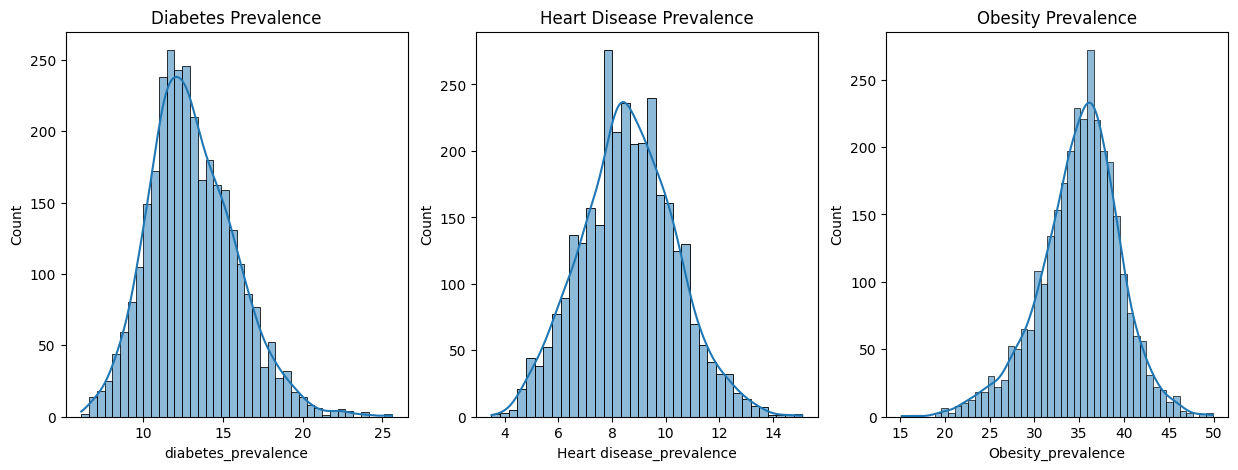

In [29]:
#miramos la normaliddad de estas 3 variables:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(df['diabetes_prevalence'], ax=axes[0], kde=True)
axes[0].set_title('Diabetes Prevalence')
sns.histplot(df['Heart disease_prevalence'], ax=axes[1], kde=True)
axes[1].set_title('Heart Disease Prevalence')
sns.histplot(df['Obesity_prevalence'], ax=axes[2], kde=True)
axes[2].set_title('Obesity Prevalence')

**Seleccionamos heart disease_prevalence por la normalidad de su distribución y por interés personal**

*Comenzamos con la limpieza...*

In [69]:
#quitamos ids
df = df.drop(columns=['fips'])

In [70]:
#miramos si hay variables con muchos valores nulos
df.isnull().sum().sort_values(ascending=False)

#no hay...

TOT_POP                     0
0-9                         0
0-9 y/o % of total pop      0
19-Oct                      0
10-19 y/o % of total pop    0
                           ..
CKD_prevalence              0
CKD_Lower 95% CI            0
CKD_Upper 95% CI            0
CKD_number                  0
Urban_rural_code            0
Length: 107, dtype: int64

In [ ]:
#revisamos multicolinealidad entre las variables
corr_matrix = df.corr(numeric_only=True)
# plt.figure(figsize=(12, 10))
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
# plt.title('Correlation Matrix')
# plt.show()

# Demasiadas variables para que visualmente sea efectivo. Lo intentaremos de nuevo cuando hayamos reducido el número de variables.

In [73]:
#Buscamos las variables con mayor correlación entre sí
# con np.triu lo que se busca es quedarnos solo con la parte superior de la matriz de correlación, para evitar redundancia y la k =1 es para no incluir la diagonal principal (que siempre es 1)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

#buscamos las columnas que tienen una correlación mayor a 0.8 aprovechando que tenemos muchas variables
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

#cuantas variables estuvieron altamente correlacionadas?
print(len(to_drop))

69


In [75]:
#elminimamos variables seleccionadas
df_reduced = df.drop(columns=to_drop)
df_reduced.shape

(3140, 38)

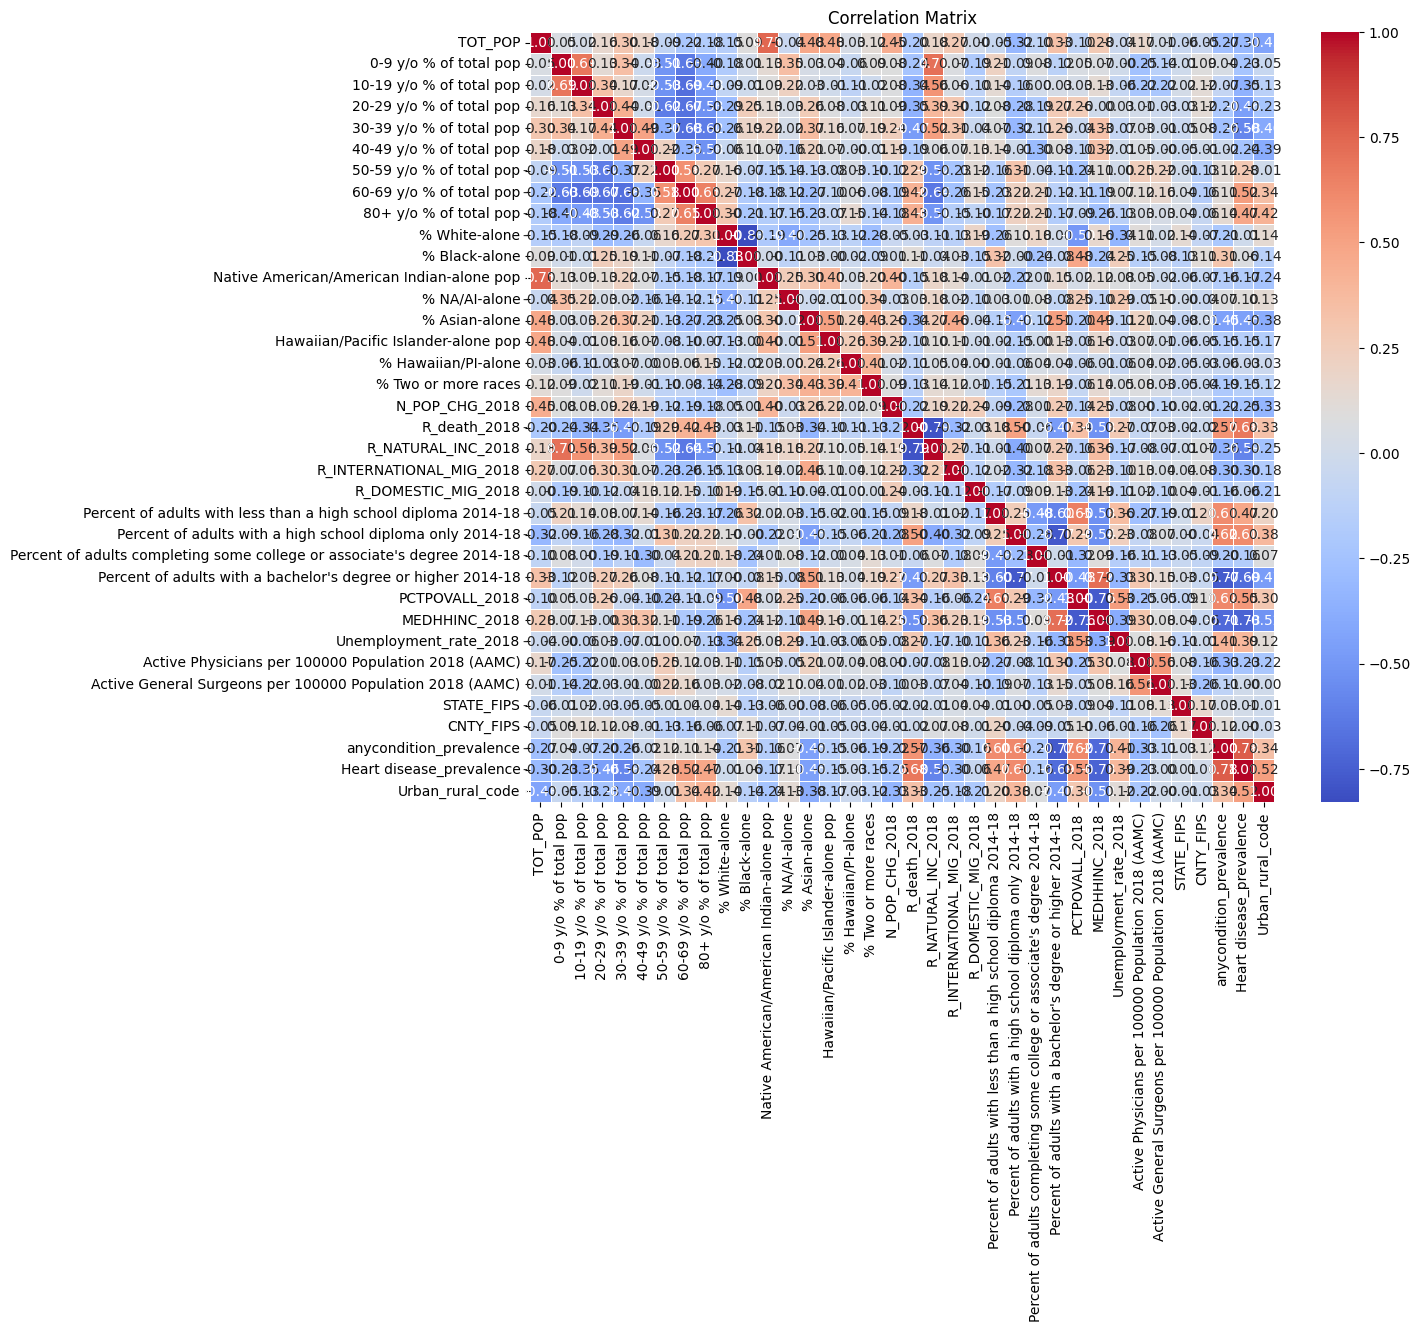

In [76]:
#probemos de nuevo con la matriz de correlación para ver si se redujo la multicolinealidad
corr_matrix = df_reduced.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [77]:
# Estadística descriptiva con las variables reducidas
df_reduced.describe()

,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,80+ y/o % of total pop,% White-alone,...,PCTPOVALL_2018,MEDHHINC_2018,Unemployment_rate_2018,Active Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),STATE_FIPS,CNTY_FIPS,anycondition_prevalence,Heart disease_prevalence,Urban_rural_code
count,3.140000e+03,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,...,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000
mean,1.041894e+05,11.871051,12.694609,12.283979,11.751535,11.556685,13.526733,13.182225,4.733801,84.494109,...,15.159459,52767.083758,4.131338,254.923567,7.621943,30.298089,103.551592,46.793917,8.607803,4.635350
std,3.335834e+05,2.124081,1.815044,3.126297,1.696599,1.372935,1.481692,2.532498,1.535028,16.348987,...,6.131874,13907.992668,1.503013,42.291759,1.288832,15.132325,107.689584,6.379448,1.758587,1.510447
min,8.800000e+01,0.000000,0.000000,0.000000,6.092789,2.631579,5.316361,3.444403,0.000000,3.841985,...,0.000000,0.000000,0.000000,191.300000,5.600000,1.000000,1.000000,22.000000,3.500000,1.000000
25%,1.096325e+04,10.594639,11.674504,10.496774,10.689322,10.685197,12.738561,11.621232,3.738648,79.620473,...,10.800000,43677.000000,3.100000,227.600000,6.900000,18.000000,35.000000,42.900000,7.400000,3.000000
50%,2.580050e+04,11.802727,12.687422,11.772649,11.580861,11.618372,13.621339,13.013409,4.565338,91.410189,...,14.100000,50564.500000,3.900000,247.100000,7.100000,29.000000,79.000000,47.200000,8.600000,5.000000
75%,6.791300e+04,12.951840,13.659282,13.182260,12.639379,12.386083,14.429115,14.467254,5.484143,95.521727,...,18.300000,58822.250000,4.800000,278.800000,8.300000,45.000000,133.000000,51.000000,9.800000,6.000000
max,1.010552e+07,25.460677,23.304372,37.570198,22.225129,19.430369,20.454545,27.272727,22.727273,99.043785,...,54.000000,140382.000000,19.900000,847.000000,25.300000,56.000000,840.000000,66.200000,15.100000,6.000000


In [78]:
#mirar todas las columnas
cols = df_reduced.columns.to_list()
for i, col in enumerate(cols):
    print(f"{i}: {col}")

0: TOT_POP
1: 0-9 y/o % of total pop
2: 10-19 y/o % of total pop
3: 20-29 y/o % of total pop
4: 30-39 y/o % of total pop
5: 40-49 y/o % of total pop
6: 50-59 y/o % of total pop
7: 60-69 y/o % of total pop
8: 80+ y/o % of total pop
9: % White-alone
10: % Black-alone
11: Native American/American Indian-alone pop
12: % NA/AI-alone
13: % Asian-alone
14: Hawaiian/Pacific Islander-alone pop
15: % Hawaiian/PI-alone
16: % Two or more races
17: N_POP_CHG_2018
18: R_death_2018
19: R_NATURAL_INC_2018
20: R_INTERNATIONAL_MIG_2018
21: R_DOMESTIC_MIG_2018
22: Percent of adults with less than a high school diploma 2014-18
23: Percent of adults with a high school diploma only 2014-18
24: Percent of adults completing some college or associate's degree 2014-18
25: Percent of adults with a bachelor's degree or higher 2014-18
26: PCTPOVALL_2018
27: MEDHHINC_2018
28: Unemployment_rate_2018
29: Active Physicians per 100000 Population 2018 (AAMC)
30: Active General Surgeons per 100000 Population 2018 (AAMC)


In [79]:
#quitemos algunas variables geográficas que no aportan nada a nuestro análisis - Dejamos Urban_rural_code porque es una variable que puede ser relevante para la salud
df_reduced = df_reduced.drop(columns=['STATE_FIPS', 'CNTY_FIPS', 'STATE_NAME','COUNTY_NAME'])

In [81]:
#anycondition_prevalence está asociada con la variable objetivo, así que la quitamos para evitar la multicolinealidad
df_reduced = df_reduced.drop(columns=['anycondition_prevalence'])

In [ ]:
#actualmente tenemos variables que podrían meter ruido por sumar el 100% como los rangos de población o la población por etnia, así que quitamos al menos uno para evitar la linealidad perfecta
df_reduced = df_reduced.drop(columns=['0-9 y/o % of total pop','% White-alone','Percent of adults with less than a high school diploma 2014-18'])

In [90]:
#hay variables con valores absolutos y en porcentaje, así que quitamos los valores absolutos para evitar la multicolinealidad
df_reduced = df_reduced.drop(columns=['Native American/American Indian-alone pop','Hawaiian/Pacific Islander-alone pop'])

In [91]:
df_reduced.shape

(3140, 28)

In [92]:
df_reduced.info()

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Data columns (total 28 columns):
 #   Column                                                                   Non-Null Count  Dtype  
---  ------                                                                   --------------  -----  
 0   TOT_POP                                                                  3140 non-null   int64  
 1   10-19 y/o % of total pop                                                 3140 non-null   float64
 2   20-29 y/o % of total pop                                                 3140 non-null   float64
 3   30-39 y/o % of total pop                                                 3140 non-null   float64
 4   40-49 y/o % of total pop                                                 3140 non-null   float64
 5   50-59 y/o % of total pop                                                 3140 non-null   float64
 6   60-69 y/o % of total pop                                                 3140 non-n

## Paso 3: Construye un modelo de regresión
Comienza a resolver el problema implementando un modelo de regresión lineal y analiza los resultados. A continuación, utilizando los mismos datos y los atributos por defecto, construye un modelo Lasso y compara los resultados con la regresión lineal base.

Analiza cómo evoluciona el R2 cuando el hiperparámetro del modelo Lasso cambia (puedes por ejemplo empezar a probar desde el valor 0.0 e ir aumentándolo hasta un valor de 20). Dibuja estos valores en un diagrama de líneas.

## Paso 4: Optimiza el modelo de regresión anterior
Después de entrenar el modelo Lasso, si los resultados no son satisfactorios, optimízalo empleando alguna de las técnicas vistas anteriormente.